In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import scipy as sp
from functools import partial
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import f1_score, cohen_kappa_score 

In [55]:
X_train = pd.read_csv("dataset/processed/X_train_featured.csv")
X_test = pd.read_csv("dataset/processed/X_test_featured.csv")
y_train = pd.read_csv("dataset/processed/y_train.csv")
y_test = pd.read_csv("dataset/processed/y_test.csv")

print("\n" + "="*40)
print("DATA SHAPE RESULTS")
print("="*40)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("-" * 40)
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


DATA SHAPE RESULTS
X_train shape: (2492096, 17)
y_train shape: (2492096, 1)
----------------------------------------
X_test shape:  (623019, 17)
y_test shape:  (623019, 1)


In [56]:
class OptimizedRounder(object):
    def __init__(self):
        self.coef_ = 0

    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 1
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 2
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        
        ll = cohen_kappa_score(y, X_p, weights='quadratic')
        return -ll

    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        # Khởi tạo ngưỡng mặc định [1.5, 2.5, 3.5]
        initial_coef = [1.5, 2.5, 3.5]
        self.coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead')

    def predict(self, X, coef):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 1
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 2
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return X_p.astype(int)

## `OptimizedRounder`: Threshold Optimization for Ordinal Regression

### **Purpose**

`OptimizedRounder` is a post-processing technique that converts continuous regression outputs into discrete ordinal labels (Severity 1–4) in a way that **maximizes Quadratic Weighted Kappa (QWK)**.

## 1. Why Do We Need This?

In ordinal classification with **imbalanced classes**, standard rounding (`round()`) is often suboptimal:

* **Rigid cut-points** at 1.5, 2.5, 3.5 fail to reflect real data distribution.
* Predictions tend to cluster around the majority class (Severity 2).
* Many severe cases (true 3 or 4) predicted as ~2.3 or 2.4 get **rounded incorrectly** to class 2.
* Result: degraded QWK and poor detection of high-severity cases.

## 2. How It Works

`OptimizedRounder` intelligently searches for **better cut-points** through three main steps:

### **Step 1 — Objective Function**

* Defines a loss function based on **negative QWK**.
* Goal: find thresholds that produce the *highest possible* QWK.

### **Step 2 — Threshold Optimization**

* Instead of fixed `[1.5, 2.5, 3.5]`, it uses numerical optimization (e.g., Nelder–Mead) to shift thresholds.
* Example: The optimal boundary between Severity 2 and 3 might be **2.8** instead of 2.5.

### **Step 3 — Apply Optimized Thresholds**

* After finding optimized boundaries (e.g., `[1.4, 2.8, 3.6]`), these are applied to convert continuous predictions into ordinal labels.

## 3. Practical Impact

Using `OptimizedRounder` provides clear benefits:

1. **Improved recall for minority classes** (Severity 3 and 4).
2. **Higher QWK** — typically a **2–5% improvement** without changing the underlying model.

**In short:** `OptimizedRounder` is a simple but powerful post-processing method that significantly boosts performance in ordinal classification problems.

In [57]:
results_table = []

def evaluate_regressor(model, X_train, y_train, X_test, y_test, model_name):
    print(f"🚀 Running evaluation for {model_name}...")
    
    # 1. PREDICTION (Predict continuous values)
    y_train = np.array(y_train).ravel()
    y_test = np.array(y_test).ravel()
    
    y_train_pred_raw = model.predict(X_train)
    y_test_pred_raw = model.predict(X_test)
    
    # 2. OPTIMIZATION
    print("   ⚖️  Optimizing QWK Thresholds...")
    opt = OptimizedRounder()
    opt.fit(y_train_pred_raw, y_train)
    coefficients = opt.coef_['x']
    print(f"      -> Best Thresholds: {coefficients}")

    y_train_pred_class = opt.predict(y_train_pred_raw, coefficients)
    y_test_pred_class = opt.predict(y_test_pred_raw, coefficients)
    
    # 3. COMPUTE METRICS
    train_f1_macro = f1_score(y_train, y_train_pred_class, average='macro')
    test_f1_macro = f1_score(y_test, y_test_pred_class, average='macro')
    
    # F1-score (classification metric)
    train_f1_weighted = f1_score(y_train, y_train_pred_class, average='weighted')
    test_f1_weighted = f1_score(y_test, y_test_pred_class, average='weighted')
    
    # Quadratic Weighted Kappa (ordinal metric)
    train_qwk = cohen_kappa_score(y_train, y_train_pred_class, weights='quadratic')
    test_qwk = cohen_kappa_score(y_test, y_test_pred_class, weights='quadratic')
    
    # 4. PRINT RESULTS
    print(f"✅ {model_name} Results (Optimized):")
    print(f"   [TRAIN] QWK: {train_qwk:.4f} | F1_macro: {train_f1_macro:.4f} | F1_weight: {train_f1_weighted:.4f}")
    print(f"   [TEST]  QWK: {test_qwk:.4f} | F1_macro: {test_f1_macro:.4f} | F1_weight: {test_f1_weighted:.4f}")

    # 5. CREATE DETAIL DF
    comp_df = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred_class,
        "y_raw": y_test_pred_raw     
    })

    # 6. PRINT PREVIEW
    print("\n   🔍 Sample predictions:")
    print(comp_df[comp_df.y_true != 2].head(10))
    
    print("-" * 70)

    # 7. RETURN RESULT DICTIONARY
    return {
        "Model": model_name,
        "F1_macro": test_f1_macro,
        "F1_weighted": test_f1_weighted,
        "QWK": test_qwk,
        "Object": model
    }

## Evaluation & Post-Processing Pipeline: `evaluate_regressor`

This function does much more than compute metrics. It implements a full **post-processing workflow** to convert continuous regression outputs into optimal ordinal class labels.

## 1. Processing Workflow

The evaluation pipeline has **three main stages**:

### **Stage 1: Raw Prediction**

* **Input:** `X_train`, `X_test`
* **Action:** The regression model outputs continuous values (e.g., `2.35`, `1.8`, `3.9`).
* **Purpose:** Preserve the underlying numeric severity ordering before converting to discrete classes.

### **Stage 2: Threshold Optimization**

This is the core ("secret sauce") of the method.

* **Init:** Instantiate the `OptimizedRounder` class.
* **Fit:** Learn optimal cut-points on the **training set** that **maximize QWK**.

  * Example: Instead of fixed thresholds at `1.5 / 2.5 / 3.5`, the optimizer may find `[1.4, 2.8, 3.6]` depending on data imbalance.
* **Predict:** Apply these learned thresholds to convert continuous predictions to discrete labels (1–4) for both Train and Test sets.

### **Stage 3: Metrics & Reporting**

The function computes the key evaluation metrics:

* **QWK (Quadratic Weighted Kappa):** The primary metric for ordinal tasks.
* **F1-Macro / F1-Weighted:** Additional measures of class balance and overall performance.
* **Sample comparison dataframe:** A small diagnostic table (`comp_df`) highlighting cases where the true label ≠ 2 — useful to check whether the model captures minority severe cases.

## 2. Inputs / Outputs

### **Inputs**

| Parameter            | Type       | Description                                                          |
| -------------------- | ---------- | -------------------------------------------------------------------- |
| `model`              | Object     | Trained regression model (XGBoost, CatBoost, LightGBM, etc.)         |
| `X_train`, `y_train` | Array / DF | Used both for fitting thresholds and evaluating training performance |
| `X_test`, `y_test`   | Array / DF | Used for final model evaluation                                      |

### **Return Value**

The function returns a clean dictionary for pushing into a Model Leaderboard:

```python
{
    "Model": "Model Name",
    "F1_macro": 0.35...,      
    "F1_weighted": 0.87...,   
    "QWK": 0.28...,           
    "Object": model           
}
```

## 3. Why This Approach Works

### 1. Handles Imbalanced Data

Learning thresholds (`opt.fit`) allows the decision boundaries to shift automatically.
Example: If class 2 dominates, the threshold between class 2 and 3 may increase → protecting minority classes.

### 2. Directly Improves QWK

Instead of optimizing Accuracy (which is misleading in imbalanced ordinal tasks), the two-step Regression → Threshold Optimization process directly maximizes QWK.

### 3. Helps Identify Risky Misclassifications

The diagnostic output `comp_df[comp_df.y_true != 2]` quickly reveals whether the model collapses everything into class 2 — a common pitfall in severity prediction.

In [58]:
print("🌲 Running Random Forest Regressor")
start = time.time()

# 1. Initialize
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# 2. Train
rf_model.fit(X_train, y_train.values.ravel())

print("\n📊 Calculating Feature Importance...")

# Create DataFrame with feature names and importance
importance_randomforest = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Evaluate
results_table.append(evaluate_regressor(rf_model, X_train, y_train.values.ravel(), X_test, y_test.values.ravel(), "Random Forest"))

print(f"⏱️ Time: {time.time()-start:.2f}s")

🌲 Running Random Forest Regressor

📊 Calculating Feature Importance...
🚀 Running evaluation for Random Forest...
   ⚖️  Optimizing QWK Thresholds...
      -> Best Thresholds: [1.62916116 2.18801297 3.64226084]
✅ Random Forest Results (Optimized):
   [TRAIN] QWK: 0.2282 | F1_macro: 0.3624 | F1_weight: 0.8684
   [TEST]  QWK: 0.2194 | F1_macro: 0.3639 | F1_weight: 0.8678

   🔍 Sample predictions:
     y_true  y_pred     y_raw
34        3       2  2.116629
43        4       3  2.508241
51        4       2  2.017733
83        4       2  2.033904
101       4       3  2.258128
111       1       2  2.019703
136       4       2  2.114000
147       4       2  2.166550
155       4       2  2.029844
177       4       3  2.314061
----------------------------------------------------------------------
⏱️ Time: 535.10s


In [59]:
weights_dict = {1: 5, 2: 3, 3: 5, 4: 10} 
sample_weights = y_train.squeeze().map(weights_dict)

In [60]:
print("🚀 Running XGBoost Regressor")
start = time.time()

# 1. Initialize with fixed parameters
xgb_model = XGBRegressor( 
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1, 
    verbosity=0 
)

# 2. Train
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

print("\n📊 Calculating Feature Importance...")
importance_xgboost = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Evaluate
results_table.append(evaluate_regressor(xgb_model, X_train, y_train, X_test, y_test, "XGBoost"))
print(f"⏱️ Time: {time.time()-start:.2f}s")

🚀 Running XGBoost Regressor

📊 Calculating Feature Importance...
🚀 Running evaluation for XGBoost...
   ⚖️  Optimizing QWK Thresholds...
      -> Best Thresholds: [1.94187736 2.45036877 2.77800251]
✅ XGBoost Results (Optimized):
   [TRAIN] QWK: 0.2355 | F1_macro: 0.3643 | F1_weight: 0.8665
   [TEST]  QWK: 0.2302 | F1_macro: 0.3636 | F1_weight: 0.8661

   🔍 Sample predictions:
     y_true  y_pred     y_raw
34        3       2  2.323537
43        4       4  2.913744
51        4       2  2.094056
83        4       2  2.144905
101       4       3  2.727529
111       1       2  2.030818
136       4       2  2.343461
147       4       3  2.456390
155       4       2  2.084889
177       4       3  2.727545
----------------------------------------------------------------------
⏱️ Time: 2190.70s


In [61]:
print("⚡ Running LightGBM Regressor")
start = time.time()

# 1. Initialize
lgbm_model = LGBMRegressor( 
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1, 
    verbose=-1 
)

# 2. Train
lgbm_model.fit(X_train, y_train, sample_weight=sample_weights)

print("\n📊 Calculating Feature Importance...")
importance_lightgbm = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Evaluate
results_table.append(evaluate_regressor(lgbm_model, X_train, y_train.values.ravel(), X_test, y_test.values.ravel(), "LightGBM"))
print(f"⏱️ Time: {time.time()-start:.2f}s")

⚡ Running LightGBM Regressor

📊 Calculating Feature Importance...
🚀 Running evaluation for LightGBM...
   ⚖️  Optimizing QWK Thresholds...
      -> Best Thresholds: [1.88677758 2.44198675 2.75797045]
✅ LightGBM Results (Optimized):
   [TRAIN] QWK: 0.2362 | F1_macro: 0.3665 | F1_weight: 0.8641
   [TEST]  QWK: 0.2321 | F1_macro: 0.3664 | F1_weight: 0.8639

   🔍 Sample predictions:
     y_true  y_pred     y_raw
34        3       2  2.342928
43        4       4  2.915284
51        4       2  2.091400
83        4       2  2.117988
101       4       3  2.664198
111       1       2  2.055398
136       4       2  2.353983
147       4       3  2.460873
155       4       2  2.042577
177       4       3  2.686174
----------------------------------------------------------------------
⏱️ Time: 284.74s


In [62]:
print("🐱 Running CatBoost Regressor")
start = time.time()

# 1. Initialize
cat_model = CatBoostRegressor(
    n_estimators=50, 
    random_state=42, 
    verbose=0
)

# 2. Train
cat_model.fit(X_train, y_train, sample_weight=sample_weights)

print("\n📊 Calculating Feature Importance...")
importance_catboost = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

# 3. Evaluate
results_table.append(evaluate_regressor(cat_model, X_train, y_train.values.ravel(), X_test, y_test.values.ravel(), "CatBoost"))
print(f"⏱️ Time: {time.time()-start:.2f}s")

🐱 Running CatBoost Regressor

📊 Calculating Feature Importance...
🚀 Running evaluation for CatBoost...
   ⚖️  Optimizing QWK Thresholds...
      -> Best Thresholds: [1.78603747 2.47170918 2.77665534]
✅ CatBoost Results (Optimized):
   [TRAIN] QWK: 0.2388 | F1_macro: 0.3743 | F1_weight: 0.8719
   [TEST]  QWK: 0.2334 | F1_macro: 0.3744 | F1_weight: 0.8715

   🔍 Sample predictions:
     y_true  y_pred     y_raw
34        3       2  2.347014
43        4       4  3.168741
51        4       2  2.088141
83        4       2  2.130915
101       4       4  2.813238
111       1       2  2.022518
136       4       2  2.415644
147       4       3  2.498459
155       4       2  1.865948
177       4       3  2.771773
----------------------------------------------------------------------
⏱️ Time: 233.75s


In [63]:
# 1. Create comparison DataFrame
df_results = pd.DataFrame(results_table)

# Sort by QWK (highest first) — prioritize ordinal agreement
df_results = df_results.sort_values(by='QWK', ascending=False)

# Columns to display
display_cols = ['Model', 'QWK', 'F1_macro', 'F1_weighted']

print("\n🏆 MODEL LEADERBOARD")
print(df_results[display_cols].to_markdown(index=False))

# 2. Select the best model based on QWK
best_model_info = df_results.iloc[0]
best_model_name = best_model_info['Model']
best_model_object = best_model_info['Object']

print(f"\n🥇 WINNER: {best_model_name}")
print(f"   with QWK: {best_model_info['QWK']:.4f}, F1_macro: {best_model_info['F1_macro']:.4f}, F1_weighted: {best_model_info['F1_weighted']:.4f}")

# 3. Save the best model
filename = f"best_model_{best_model_name.replace(' ', '_')}.pkl"
joblib.dump(best_model_object, filename)
print(f"💾 Saved the best model to file: {filename}")


🏆 MODEL LEADERBOARD
| Model         |      QWK |   F1_macro |   F1_weighted |
|:--------------|---------:|-----------:|--------------:|
| CatBoost      | 0.233384 |   0.374365 |      0.87145  |
| LightGBM      | 0.232077 |   0.366424 |      0.863925 |
| XGBoost       | 0.230173 |   0.363579 |      0.866084 |
| Random Forest | 0.219355 |   0.363864 |      0.867769 |

🥇 WINNER: CatBoost
   with QWK: 0.2334, F1_macro: 0.3744, F1_weighted: 0.8715
💾 Saved the best model to file: best_model_CatBoost.pkl


## **Comparative Performance**

### *(Ordinal Classification — Severity Prediction)*

## 1. Executive Summary

These models aim to predict **accident severity (1–4)**, which is an **ordinal classification problem** — meaning the classes follow a natural order and misclassifications **do not carry equal cost**.

Because of this ordering, the most meaningful metric is **Quadratic Weighted Kappa (QWK)**, which penalizes *large ordinal mistakes* more heavily and better reflects real-world severity differences.

After applying a comprehensive preprocessing pipeline (Missing Value Handling, Outlier Removal, Encoding, Feature Engineering, Class Weighting), model performance reshaped significantly:

* From **QWK < 0.17** → **QWK ≈ 0.23**
* Boosting models improved dramatically in ordinal consistency
* F1-Weighted decreased slightly but became **more realistic and honest**

> **Highlight:**  
> After preprocessing, **CatBoost** emerged as the strongest performer (QWK = **0.2334**), reinforcing the principle:  
> **“Even powerful algorithms fail on poor-quality data.”**

## 2. Before vs. After Performance Comparison

| Model             | QWK (Before) | QWK (After) | Growth | Status             |
| ----------------- | :----------: | :---------: | :----: | ------------------ |
| **CatBoost**      |   0.1205     | **0.2334**  | +94%   | 🏆 Champion        |
| **LightGBM**      |   0.0777     |   0.2321    | +198%  | Biggest jump       |
| **XGBoost**       |   0.0890     |   0.2301    | +158%  | Strong recovery    |
| **Random Forest** |   0.1633     |   0.2193    | +34%   | Stable improvement |

**Observation:**  
All models converge around **QWK ≈ 0.23**, showing that the performance ceiling is currently **limited by data quality rather than algorithm choice**.

## 3. In-Depth Analysis

### A. Why Boosting Models Improved the Most (CatBoost, LightGBM, XGBoost)

#### **Before preprocessing → QWK ≈ 0.08–0.12**

Boosting algorithms perform poorly when:

* Features contain noise or extreme outliers  
* Missing values are not handled properly  
* Categorical encoding is inconsistent  
* Features lack contextual meaning  

They tend to “chase noise,” leading to weak ordinal reasoning.

#### **After preprocessing → QWK ≈ 0.23**

Once the data became cleaner and more structured, Boosting models benefited from:

* Reduced variance  
* Better gradient behavior  
* More meaningful feature splits  
* Improved recognition of ordinal progression among severity labels  

This allowed them to leverage their true strength in capturing complex relationships.

### B. Why F1-Weighted Dropped — and Why This Is a Good Sign

#### **Before preprocessing — artificially high F1-weighted (~0.91)**

The dataset is heavily imbalanced (Severity 2 dominates), allowing a naive model to:

* Predict “2” for most cases  
* Achieve high F1-weighted despite being useless  
* Miss almost all severe classes (3 and 4)  

This gave a **misleading illusion of high performance**.

#### **After preprocessing — F1-weighted decreases to ~0.86–0.87**

The model now:

* Reduces overreliance on the majority class  
* Detects minority classes more reliably  
* Makes fewer trivial predictions  
* Gains better ordinal consistency (reflected in QWK)  

👉 **Lower F1, but a much smarter and fairer model.**

## 4. Why QWK Matters More than F1-Weighted

Since this is an **ordinal classification task**, the order:
1 < 2 < 3 < 4

carries essential information.

Prediction errors have different severities:

* Predicting **2 instead of 3** → small mistake  
* Predicting **1 instead of 4** → severe mistake with serious impact  

### Why F1-Weighted is insufficient

* Treats all errors equally  
* Ignores ordinal structure  
* Inflates performance on imbalanced datasets  
* Can remain high even when the model fails real-world requirements  

### Why QWK is ideal

* Penalizes predictions based on *how far they are* from the true label  
* Rewards ordinal agreement  
* Captures meaningful severity differences  
* Standard metric for rating/severity-based tasks  

👉 **QWK reflects real-world consequences; F1 does not.**

## 5. Technical Conclusions

Data preprocessing fundamentally transformed the modeling results:

1. **Models shifted from memorizing noise → to learning meaningful patterns**  
2. **Boosting models unlocked their real potential** through cleaner data  
3. **Evaluation became more meaningful**, moving from misleading F1 to informative QWK  
4. **All models converged**, confirming that **data quality is the true performance bottleneck**  

> “Garbage in → Garbage out.”  
> The improvements prove that high-quality data is the foundation of intelligent models.

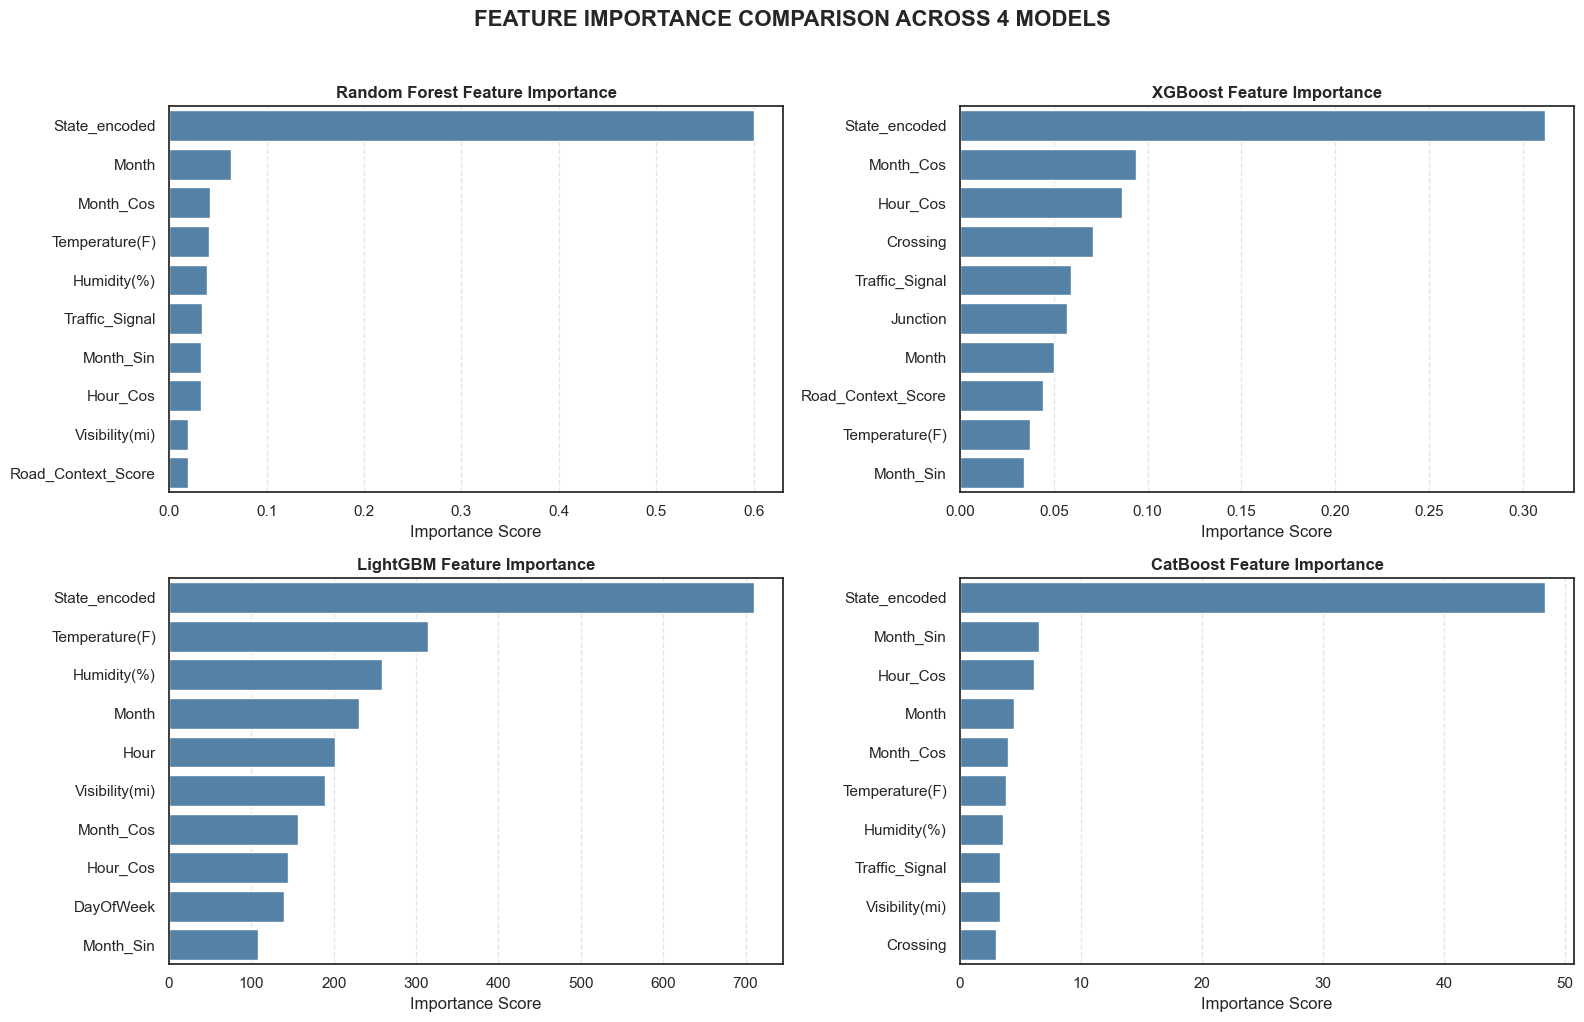

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('FEATURE IMPORTANCE COMPARISON ACROSS 4 MODELS', fontsize=16, fontweight='bold', y=1.02)

models_info = [
    (importance_randomforest, "Random Forest", axes[0, 0]),
    (importance_xgboost, "XGBoost", axes[0, 1]),
    (importance_lightgbm, "LightGBM", axes[1, 0]),
    (importance_catboost, "CatBoost", axes[1, 1])
]

for df, name, ax in models_info:
    df_sorted = df.sort_values(by='Importance', ascending=False).head(10)
    
    sns.barplot(
        data=df_sorted, 
        x='Importance', 
        y='Feature', 
        color='steelblue',
        ax=ax
    )
    
    ax.set_title(f'{name} Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Feature Importance Analysis**

### 1. Geographic Features Dominate
* **`State_encoded`** is the most important feature across **all four models**.
* This confirms that **location-related factors** (infrastructure, climate, traffic density by state) are the strongest predictors of accident severity.

### 2. Cyclical Time Features Perform Extremely Well
* Features like **`Month_Sin`**, **`Month_Cos`**, and **`Hour_Cos`** consistently appear in the top rankings.
* This shows that models strongly benefit from capturing **seasonality** and **time-of-day patterns**.

### 3. LightGBM & Random Forest Prefer Environmental Variables
* Continuous environmental features such as **`Temperature(F)`**, **`Humidity(%)`**, and **`Visibility(mi)`** rank high in LightGBM and RF.
* XGBoost and CatBoost rely less on these, highlighting differences in model behavior.

### 4. Infrastructure Features Still Matter
* Features including **`Traffic_Signal`**, **`Crossing`**, **`Junction`**, and **`Road_Context_Score`** appear consistently across models.
* They are not the top drivers but provide meaningful context about the traffic environment.

---

# Why We Use **Regression** Instead of Pure Classification

Although the target variable `Severity` takes discrete values `{1, 2, 3, 4}`, this is not a nominal multi-class problem. It is an **ordinal classification** task, where class order matters.
For this reason, we choose **Regression + Threshold Optimization** rather than a standard Classifier.

## 1. Preserving Ordinality

* **Classification:** Treats classes as independent labels (e.g., Dog / Cat / Bird). Misclassifying true `4 → 1` is penalized the same as `4 → 3`.
* **Regression:** Naturally understands the ordered relationship `1 < 2 < 3 < 4`.
  The model learns that Severity 4 is closer to 3 than to 1, preserving the structure of the data.

## 2. Distance-Sensitive Loss (Aligned With QWK)

The main evaluation metric is **Quadratic Weighted Kappa (QWK)**, which penalizes large misclassifications more heavily.

| Case  | True | Pred | Error | Classification Penalty | Regression / QWK Penalty |
| ----- | :--: | :--: | :---: | :--------------------: | :----------------------: |
| **A** |   4  |   3  |   1   |  Wrong (same penalty)  |       Mild (SE = 1)      |
| **B** |   4  |   1  |   3   |  Wrong (same penalty)  |    **Severe (SE = 9)**   |

👉 **Regression minimizes squared error**, which is conceptually aligned with how QWK evaluates mistakes.
This helps avoid dangerous large-gap errors (e.g., predicting Severe-4 as 1).

## 3. Flexible Decision Boundaries (Key for Imbalanced Data)

This is the “secret weapon” of the approach:

* **Classification:** Chooses the class with highest probability (rigid argmax).
* **Regression:** Produces continuous outputs like `2.35`, `2.82`.

Instead of hard thresholds at `1.5 / 2.5 / 3.5`, we apply **Optimized Rounder** to find **data-driven cut-points**.

*Example:*
If class 2 dominates, the optimal threshold between class 2 and 3 might shift from **2.5 → 2.8**, reducing misclassification caused by imbalance.

##  Summary

Using **Regression + Optimized Thresholds** offers:

* Better preservation of the ordinal structure
* Loss behavior aligned with QWK
* Flexible boundaries that handle imbalance
* **Significantly higher QWK** than traditional multi-class classifiers

This makes regression the superior choice for severity prediction tasks.